# 05 - Evaluation

Loads the results of the full pipeline run (`evaluation/reports/metrics.json`, produced by `run_pipeline.py`) and walks through the held-out test-set evaluation: classification metrics, cost-sensitive analysis, and abuse-ring detection quality.

In [1]:
import json
import pandas as pd
from pathlib import Path

metrics = json.loads(Path('evaluation/reports/metrics.json').read_text())
metrics['temporal_split']

{'train_txns': 78057,
 'val_txns': 9654,
 'test_txns': 9713,
 'train_fraud_rate': 0.0534,
 'val_fraud_rate': 0.0494,
 'test_fraud_rate': 0.0651}

## Classification metrics (held-out October test set)

In [2]:
pd.Series(metrics['classification_metrics'])

precision    0.9457
recall       0.9652
f1           0.9554
roc_auc      0.9966
pr_auc       0.9819
dtype: float64

## Cost-sensitive evaluation

Accuracy is not the headline metric here -- fraud is a 6.5% minority class with highly asymmetric costs. See `evaluation/metrics.py` for `cost_analysis()`.

In [3]:
cost = metrics['cost_analysis']
baseline = metrics['baseline_ml_only_cost_analysis']
comparison = pd.DataFrame({'Fused model': cost, 'ML-only baseline': baseline}).T
comparison

,cost_per_false_positive,cost_per_false_negative,expected_fp_cost_inr,expected_fn_cost_inr,total_expected_cost_inr
Fused model,100,2000,3500,44000,47500
ML-only baseline,100,2000,19500,32000,51500


In [4]:
print(f"Cost reduction from fusion vs ML-only baseline: {metrics['cost_reduction_vs_ml_only_baseline_pct']}%")
print(f"Cost-optimal threshold (tuned on validation set): {metrics['optimal_threshold']}")

Cost reduction from fusion vs ML-only baseline: 7.77%
Cost-optimal threshold (tuned on validation set): 0.29


## Abuse ring detection quality

In [5]:
pd.Series(metrics['ring_detection_metrics'])

clusters_found       42.0000
cluster_precision     1.0000
cluster_recall        0.9928
avg_cluster_size      9.7900
dtype: float64

## Evaluation plots

(Precision-recall curve, ROC curve, cost-vs-threshold sweep, risk score distribution)

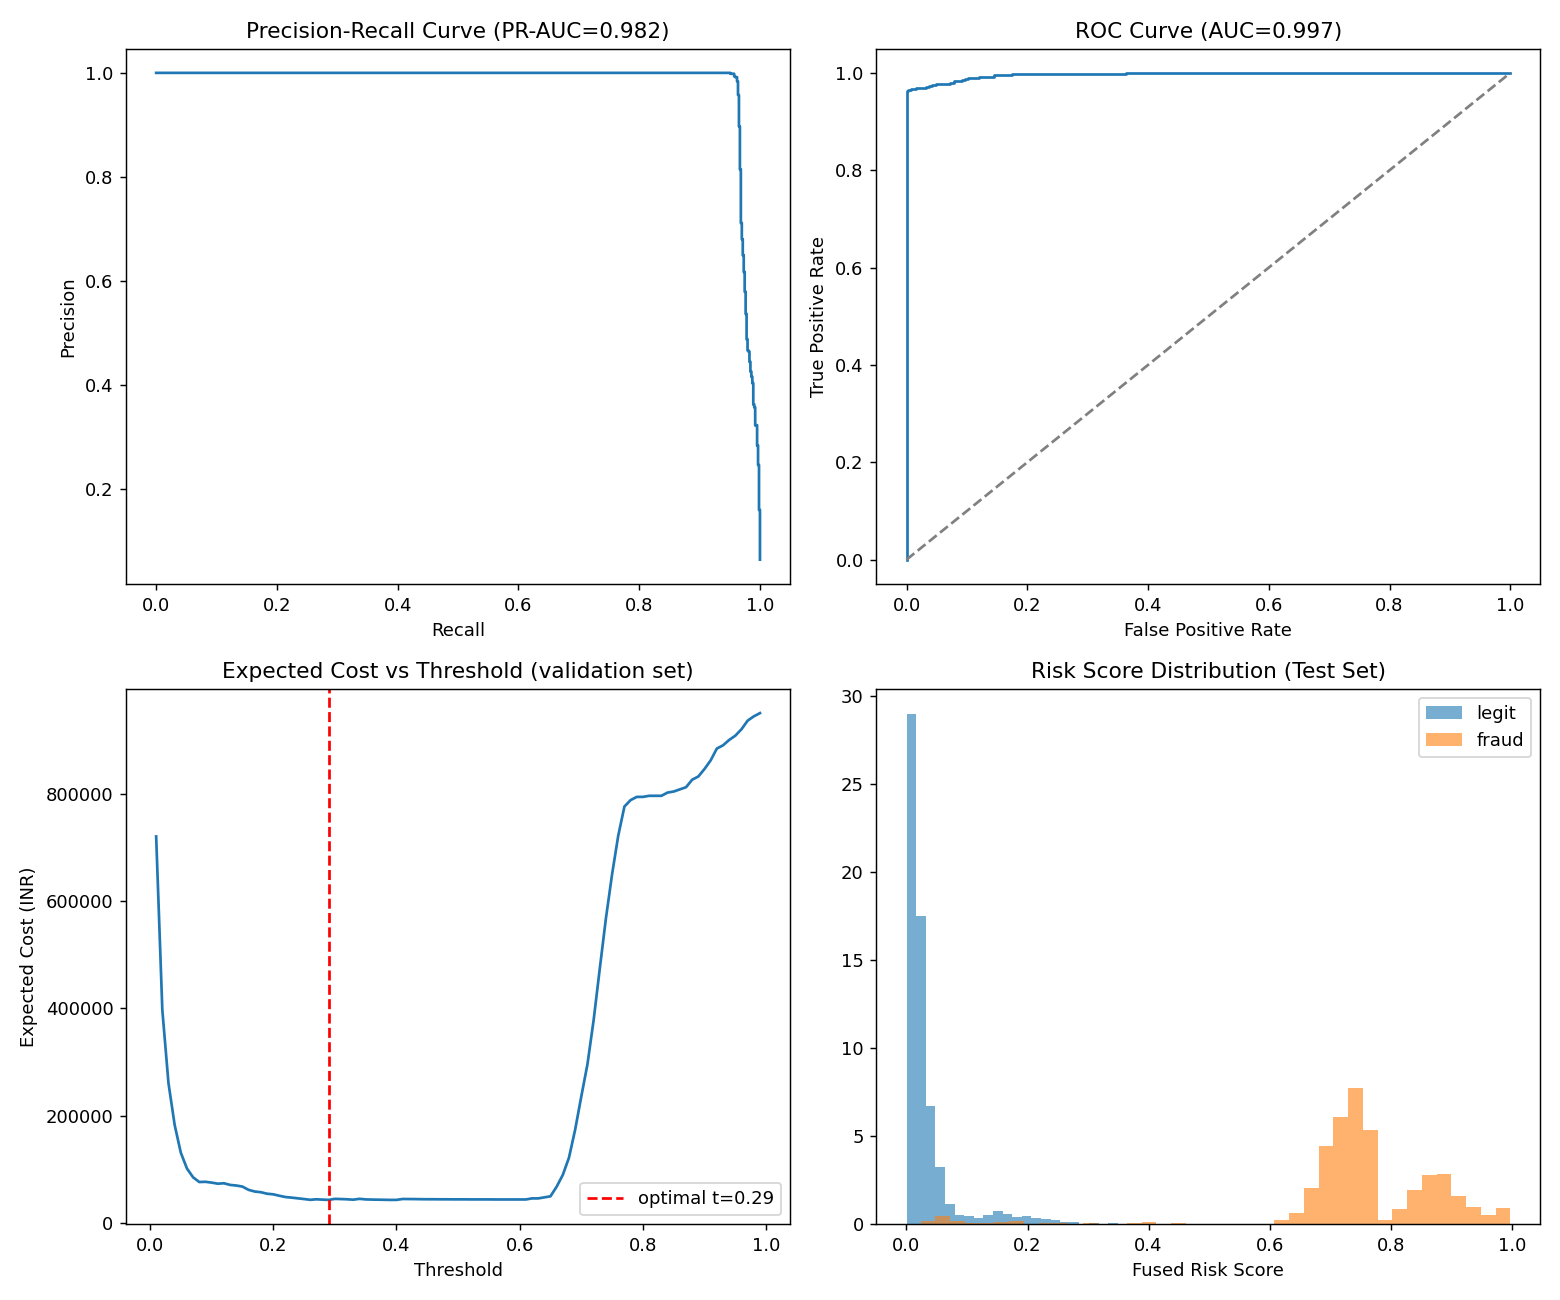

In [6]:
from IPython.display import Image
Image(filename='evaluation/reports/evaluation_plots.png')

## Sample investigations (agent + policy engine output on top alerts)

In [7]:
for ex in metrics['sample_investigations'][:3]:
    print(f"[{ex['risk_level']}] {ex['transaction_id']}  score={ex['risk_score']:.2f}  "
          f"truth={'FRAUD' if ex['ground_truth_label'] else 'legit'} ({ex['ground_truth_scenario']})")
    print(f"  -> {ex['investigation_summary']}")
    print(f"  -> agent recommends: {ex['agent_recommended_action']}, policy sets: {ex['policy_final_action']}")
    print()

[CRITICAL] TXN_cc5d98221a  score=1.00  truth=FRAUD (abuse_ring)
  -> This transaction (₹3606) was flagged with a risk score of 1.00 (CRITICAL). Key contributing signals: IP address is shared across multiple customer accounts; amount is 6.2x this customer's historical average; ip_customer_count = 8. The associated device/IP is part of a network of 40 accounts, consistent with coordinated abuse rather than an isolated incident. 15 related transactions were found for this customer/device/IP cluster within the recent window.
  -> agent recommends: recommend_hold, policy sets: recommend_hold

[CRITICAL] TXN_4745f56817  score=1.00  truth=FRAUD (abuse_ring)
  -> This transaction (₹3802) was flagged with a risk score of 1.00 (CRITICAL). Key contributing signals: IP address is shared across multiple customer accounts; amount is 28.7x this customer's historical average; ip_customer_count = 5. The associated device/IP is part of a network of 40 accounts, consistent with coordinated abuse rather t